In [1]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel(r'OneDrive\Documents\MIS 581\MIS 581 - Mod 8 - Modeling 30d Readmission Dataset.xlsx')

In [2]:
# Display first 5 rows to view basic structure
df.head()

,age,gender_female,dispo_post_acute,dispo_transfer,dispo_ama,los_days_capped,infection_flag,adm_dx_sepsis,adm_dx_pna,adm_dx_hf,...,med_risk_high,ed_low,ed_moderate,ed_high,ip_admit_utilization_low,ip_admit_utilization_moderate,ip_admit_utilization_high,icu_admit_flag,rrt_flag,readmit_30d
0,30,0,0,0,0,2,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
1,73,0,0,0,0,3,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,81,1,0,0,0,2,0,0,0,1,...,0,1,0,0,0,1,0,0,0,0
3,83,0,1,0,0,5,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
4,75,0,0,0,0,3,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0


In [3]:
# Check data types and null value counts for each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26014 entries, 0 to 26013
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   age                            26014 non-null  int64
 1   gender_female                  26014 non-null  int64
 2   dispo_post_acute               26014 non-null  int64
 3   dispo_transfer                 26014 non-null  int64
 4   dispo_ama                      26014 non-null  int64
 5   los_days_capped                26014 non-null  int64
 6   infection_flag                 26014 non-null  int64
 7   adm_dx_sepsis                  26014 non-null  int64
 8   adm_dx_pna                     26014 non-null  int64
 9   adm_dx_hf                      26014 non-null  int64
 10  adm_dx_copd                    26014 non-null  int64
 11  adm_dx_rf                      26014 non-null  int64
 12  adm_dx_aki                     26014 non-null  int64
 13  mort_risk_medium

In [4]:
# Display descriptive stats of the discrete numeric variables
df[['age','los_days_capped']].describe().round(2)

,age,los_days_capped
count,26014.00,26014.00
mean,55.25,3.78
std,20.97,4.08
min,18.00,0.00
25%,35.00,2.00
50%,59.00,3.00
75%,73.00,4.00
max,104.00,30.00


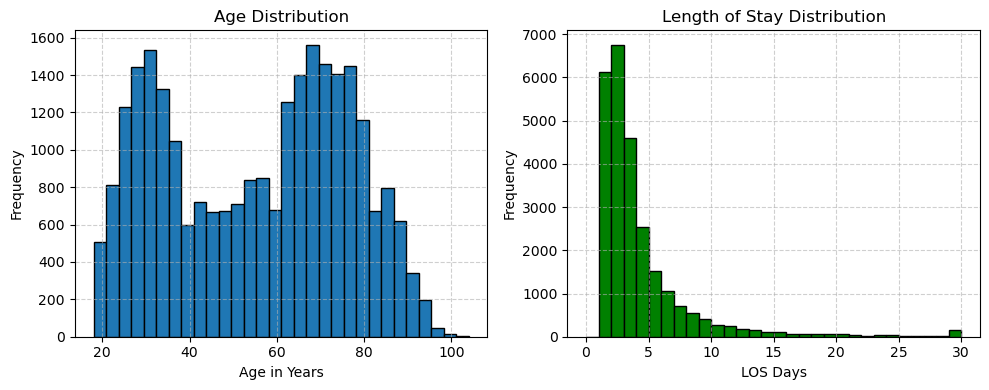

In [5]:
# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

## Age histogram formatting/parameters
axes[0].hist(df['age'], bins=30, edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age in Years')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Length of Stay (LOS) histogram formatting/parameters
axes[1].hist(df['los_days_capped'], bins=30, color='green', edgecolor='black')
axes[1].set_title('Length of Stay Distribution')
axes[1].set_xlabel('LOS Days')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.6)

## Plot the side-by-side histograms
plt.tight_layout()
plt.show()

In [6]:
# Create summary table of the binary indicator variables and 
# reference groups

## Create empty list to store summary table rows
summary_rows = []

## Create function to calculate summary statistics for a subgroup
def add_group(group, category, subset):
    summary_rows.append({
        "Variable Group": group,
        "Category": category,
        "Count": len(subset),
        "% of Total": len(subset) / len(df) * 100,
        "Readmission Rate": subset["readmit_30d"].mean() * 100
    })


## Create a dictionary containing the variable group names, 
## the binary variables, and reference group lables
binary_vars = {
    "Gender": {
        "gender_female": "(Reference) gender_male"
    },
    "Clinical Indicators": {
        "infection_flag": "(Reference) no_infection",
        "icu_admit_flag": "(Reference) no_icu_admit",
        "rrt_flag": "(Reference) no_rrt"
    }
}

## Loop through each variable group
for group, variables in binary_vars.items():
    
    ### Loop through each binary variable
    for var, ref_label in variables.items():
        
        ### Create subgroup where variable = 1
        add_group(group, var, df[df[var] == 1])
        
        ### Create subgroup where variable = 0
        add_group(group, ref_label, df[df[var] == 0])

## Convert results into a pandas DataFrame
summary_table = pd.DataFrame(summary_rows)

## Round percentage columns to 1 decimal place
summary_table["% of Total"] = summary_table["% of Total"].round(1)
summary_table["Readmission Rate"] = summary_table["Readmission Rate"].round(1)

## Display the summary table
summary_table

,Variable Group,Category,Count,% of Total,Readmission Rate
0,Gender,gender_female,15364,59.1,8.2
1,Gender,(Reference) gender_male,10650,40.9,10.8
2,Clinical Indicators,infection_flag,1720,6.6,19.2
3,Clinical Indicators,(Reference) no_infection,24294,93.4,8.6
4,Clinical Indicators,icu_admit_flag,3815,14.7,12.7
5,Clinical Indicators,(Reference) no_icu_admit,22199,85.3,8.7
6,Clinical Indicators,rrt_flag,2352,9.0,13.1
7,Clinical Indicators,(Reference) no_rrt,23662,91.0,8.9


In [7]:
# Create summary table of the admission diagnosis binary indicator 
# variables and reference groups

## Create empty list to store summary table rows
summary_rows2 = []


## Create function to calculate summary statistics for a subgroup
def add_group2(group, category, subset):
    summary_rows2.append({
        "Variable Group": group,
        "Category": category,
        "Count": len(subset),
        "% of Total": len(subset) / len(df) * 100,
        "Readmission Rate": subset["readmit_30d"].mean() * 100
    })


## Admission dx variables and reference labels
dx_vars = {
    "adm_dx_sepsis": "(Reference) no_sepsis",
    "adm_dx_pna": "(Reference) no_pna",
    "adm_dx_hf": "(Reference) no_hf",
    "adm_dx_copd": "(Reference) no_copd",
    "adm_dx_rf": "(Reference) no_rf",
    "adm_dx_aki": "(Reference) no_aki"
}


## Loop through each admission dx variable
for var, ref_label in dx_vars.items():

    ### Patients with the dx
    add_group2("Admission Diagnoses", var, df[df[var] == 1])

    ### Patients without the dx (reference group)
    add_group2("Admission Diagnoses", ref_label, df[df[var] == 0])


## Convert results into a pandas DataFrame
summary_table2 = pd.DataFrame(summary_rows2)


## Round percentage columns to 1 decimal place
summary_table2["% of Total"] = summary_table2["% of Total"].round(1)
summary_table2["Readmission Rate"] = summary_table2["Readmission Rate"].round(1)


## Display the summary table
summary_table2

,Variable Group,Category,Count,% of Total,Readmission Rate
0,Admission Diagnoses,adm_dx_sepsis,611,2.3,14.2
1,Admission Diagnoses,(Reference) no_sepsis,25403,97.7,9.2
2,Admission Diagnoses,adm_dx_pna,1114,4.3,11.3
3,Admission Diagnoses,(Reference) no_pna,24900,95.7,9.2
4,Admission Diagnoses,adm_dx_hf,739,2.8,14.9
5,Admission Diagnoses,(Reference) no_hf,25275,97.2,9.1
6,Admission Diagnoses,adm_dx_copd,472,1.8,14.6
7,Admission Diagnoses,(Reference) no_copd,25542,98.2,9.2
8,Admission Diagnoses,adm_dx_rf,1370,5.3,12.3
9,Admission Diagnoses,(Reference) no_rf,24644,94.7,9.1


In [8]:
# Create summary table of the one-hot encoded variables and their reference groups

## Create empty list to store summary table rows
summary_rows3 = []


## Function to calculate summary statistics for a subgroup
def add_group3(group, category, subset):
    summary_rows3.append({
        "Variable Group": group,
        "Category": category,
        "Count": len(subset),
        "% of Total": len(subset) / len(df) * 100,
        "Readmission Rate": subset["readmit_30d"].mean() * 100  # Readmission rate
    })


## One-hot encoded variables and reference groups
onehot_groups = {
    "Discharge Disposition": {
        "categories": ["dispo_post_acute", "dispo_transfer", "dispo_ama"],
        "reference": "(Reference) dispo_home"
    },
    "Mortality Risk": {
        "categories": ["mort_risk_medium", "mort_risk_high", "mort_risk_missing"],
        "reference": "(Reference) mort_risk_low"
    },
    "Medication Risk": {
        "categories": ["med_risk_medium", "med_risk_high"],
        "reference": "(Reference) med_risk_low"
    },
    "ED Utilization": {
        "categories": ["ed_low", "ed_moderate", "ed_high"],
        "reference": "(Reference) ed_none"
    },
    "Inpatient Utilization": {
        "categories": [
            "ip_admit_utilization_low",
            "ip_admit_utilization_moderate",
            "ip_admit_utilization_high"
        ],
        "reference": "(Reference) ip_admit_utilization_none"
    }
}


## Loop through each one-hot encoded variable group
for group, info in onehot_groups.items():

    ### Get category column names
    cols = info["categories"]

    ### Reference group = patients with 0 for all columns in that group
    add_group3(group, info["reference"], df[df[cols].sum(axis=1) == 0])

    ### Add one row for each category in the group
    for col in cols:
        add_group3(group, col, df[df[col] == 1])


## Convert results into a pandas DataFrame
summary_table3 = pd.DataFrame(summary_rows3)


## Round percentage columns to 1 decimal place
summary_table3["% of Total"] = summary_table3["% of Total"].round(1)
summary_table3["Readmission Rate"] = summary_table3["Readmission Rate"].round(1)


## Display the summary table
summary_table3

,Variable Group,Category,Count,% of Total,Readmission Rate
0,Discharge Disposition,(Reference) dispo_home,21984,84.5,8.2
1,Discharge Disposition,dispo_post_acute,3382,13.0,12.2
2,Discharge Disposition,dispo_transfer,217,0.8,49.8
3,Discharge Disposition,dispo_ama,431,1.7,18.6
4,Mortality Risk,(Reference) mort_risk_low,15492,59.6,6.7
5,Mortality Risk,mort_risk_medium,3717,14.3,14.3
6,Mortality Risk,mort_risk_high,2566,9.9,18.7
7,Mortality Risk,mort_risk_missing,4239,16.3,8.8
8,Medication Risk,(Reference) med_risk_low,13937,53.6,6.0
9,Medication Risk,med_risk_medium,9790,37.6,9.6


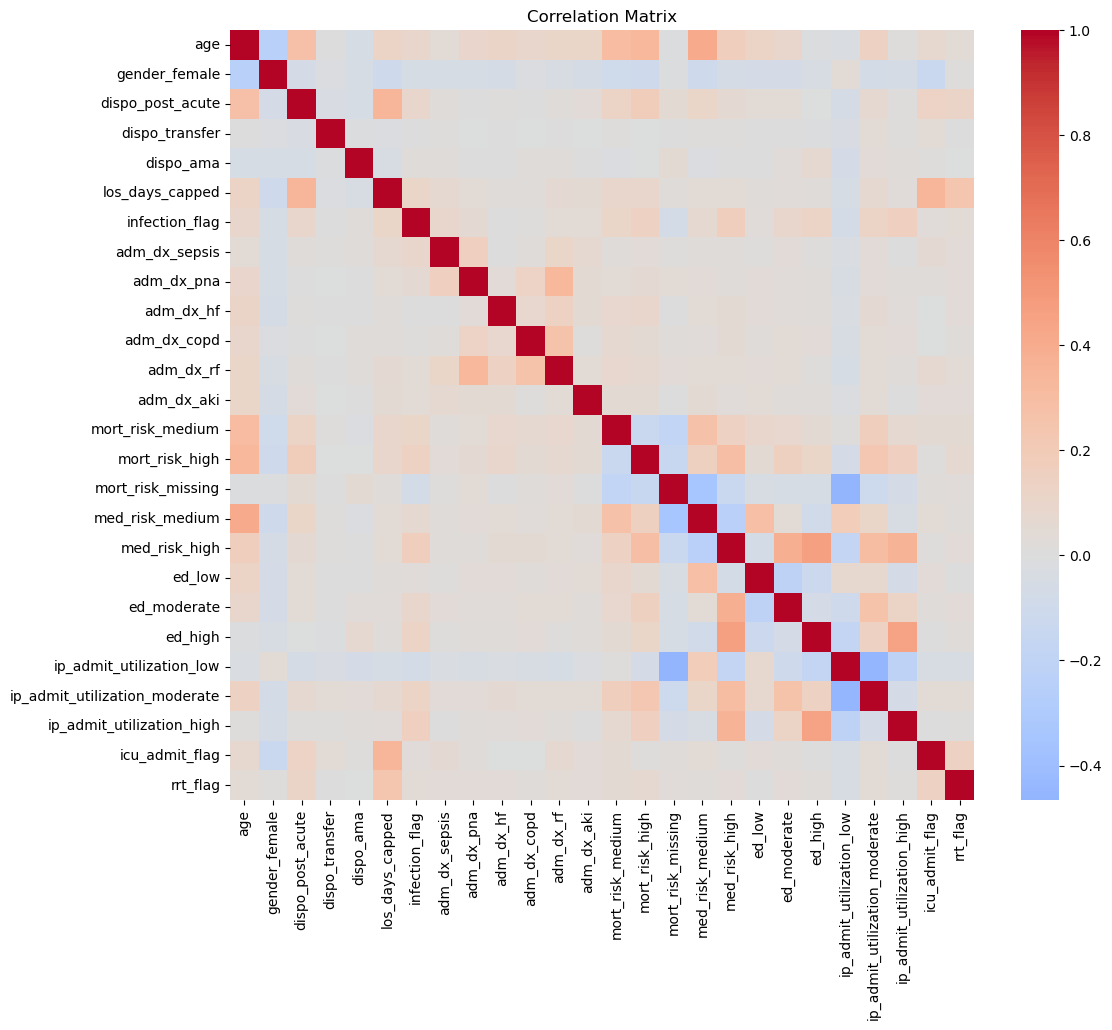

In [9]:
# Create a correlation matrix to assess multicollinearity
corr = df.drop(columns=['readmit_30d']).corr()

# Plot the matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Matrix")

# Display the matrix
plt.show()

In [11]:
# Calculate Variance Inflation Factor (VIF) to assess multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

## Remove outcome variable
X = df.drop(columns=['readmit_30d'])

## Add constant (intercept) term required for VIF calculation
X = sm.add_constant(X)

## Create pandas DataFrame for VIF results and store variable names
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

## Calculate a VIF value for each predictor variable
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

## Remove constant term from VIF table
vif_data = vif_data[vif_data["Feature"] != "const"]

## Sort results from highest to lowest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

## Display results table
vif_data

,Feature,VIF
18,med_risk_high,2.565690
22,ip_admit_utilization_low,2.282701
17,med_risk_medium,2.114802
23,ip_admit_utilization_moderate,2.052613
16,mort_risk_missing,2.012789
1,age,1.808526
21,ed_high,1.794962
24,ip_admit_utilization_high,1.644281
20,ed_moderate,1.614120
15,mort_risk_high,1.500663


In [12]:
#### LOGISTIC REGRESSION ####

# Create a logistic regression (LR) model

## Define X and y for LR model
X = df.drop(columns=['readmit_30d'])
y = df['readmit_30d']

## Import train/test split function
from sklearn.model_selection import train_test_split

## Create training and testing subsets (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 123,
    stratify = y
)

In [13]:
## Import LR model
from sklearn.linear_model import LogisticRegression

## Fit LR model (w/ balanced class weighting)
lr = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced'
)

## Train LR model
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [14]:
## Make predictions
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

## Import AUC function
from sklearn.metrics import roc_auc_score

## Calculate AUC value
auc = roc_auc_score(y_test, y_prob)

## Display AUC value
print("LR AUC:", auc)

LR AUC: 0.7467548946250216


In [15]:
## Import confusion matrix function
from sklearn.metrics import confusion_matrix

## Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred)

## Display results
print("LR Confusion Matrix (Threshold = 0.5)")
print("______________________________________")
print(cm_lr)

LR Confusion Matrix (Threshold = 0.5)
______________________________________
[[5759 1322]
 [ 318  406]]


In [16]:
## Import the classifciation report function
from sklearn.metrics import classification_report

## Create and display a classification report
print("LR Classification Report (Threshold = 0.5)")
print("_____________________________________________________")
print(classification_report(y_test, y_pred))

LR Classification Report (Threshold = 0.5)
_____________________________________________________
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      7081
           1       0.23      0.56      0.33       724

    accuracy                           0.79      7805
   macro avg       0.59      0.69      0.60      7805
weighted avg       0.88      0.79      0.82      7805



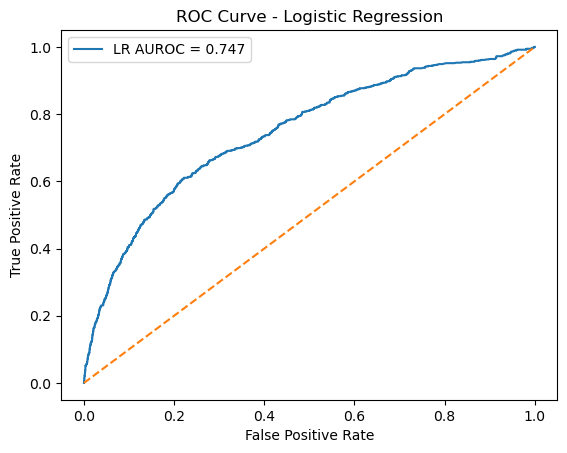

In [17]:
## Import ROC curve function
from sklearn.metrics import roc_curve

## Calculate false positive rate (FPR) and true positive
## rate (TPR) across all classification thresholds
fpr, tpr, _ = roc_curve(y_test, y_prob)

## Plot ROC curve
plt.plot(fpr, tpr, label=f"LR AUROC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

## Display the ROC curve
plt.show()

In [18]:
## Create table of LR predictor variable coefficients
coefficients = pd.DataFrame({
    'LR Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

## Caclulate odds ratios for each predictor variable
coefficients['Odds Ratio'] = np.exp(coefficients['Coefficient'])

## Display feature importance table
coefficients

,LR Feature,Coefficient,Odds Ratio
3,dispo_transfer,2.506240,12.258750
23,ip_admit_utilization_high,1.860507,6.426996
22,ip_admit_utilization_moderate,1.470488,4.351357
17,med_risk_high,1.330611,3.783354
4,dispo_ama,0.797388,2.219735
15,mort_risk_missing,0.716002,2.046235
16,med_risk_medium,0.462759,1.588451
7,adm_dx_sepsis,0.276104,1.317984
12,adm_dx_aki,0.260084,1.297039
9,adm_dx_hf,0.238570,1.269433


In [19]:
## Check 0.3 classification threshold
y_pred_03 = (y_prob >= 0.3).astype(int)

## Create a confusion matrix with 0.3 threshold
cm_03 = confusion_matrix(y_test, y_pred_03)

## Display the confusion matrix
print("LR Confusion Matrix (Threshold = 0.3)")
print("______________________________________")
print(cm_03)

LR Confusion Matrix (Threshold = 0.3)
______________________________________
[[2485 4596]
 [  82  642]]


In [20]:
## Create and display the classfication report with 0.3 threshold
print("LR Classification Report (Threshold = 0.3)")
print("_____________________________________________________")
print(classification_report(y_test, y_pred_03))

LR Classification Report (Threshold = 0.3)
_____________________________________________________
              precision    recall  f1-score   support

           0       0.97      0.35      0.52      7081
           1       0.12      0.89      0.22       724

    accuracy                           0.40      7805
   macro avg       0.55      0.62      0.37      7805
weighted avg       0.89      0.40      0.49      7805



In [21]:
#### RANDOM FOREST ####

# Create a Random Forest machine learning model

## Import Random Forest (RF) model
from sklearn.ensemble import RandomForestClassifier

## Create the Random Forest model (w/ 'balanced' class weight)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=123,
    n_jobs=-1
)

## Train the model
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=200, n_jobs=-1,
                       random_state=123)

In [22]:
# Make predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

## Calculate RF AUC value
auc_rf = roc_auc_score(y_test, y_prob_rf)

## Display RF AUC value
print("RF AUC:", auc_rf)

RF AUC: 0.7491112119351373


In [23]:
## Create a confusion matrix for the RF model
cm_rf = confusion_matrix(y_test, y_pred_rf)

## Display the results
print("RF Confusion Matrix (Threshold - 0.5)")
print("______________________________________")
print(cm_rf)

RF Confusion Matrix (Threshold - 0.5)
______________________________________
[[6013 1068]
 [ 363  361]]


In [24]:
## Create and display the classification report for the RF model
print("RF Classification Report (Threshold = 0.5)")
print("_____________________________________________________")
print(classification_report(y_test, y_pred_rf))

RF Classification Report (Threshold = 0.5)
_____________________________________________________
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      7081
           1       0.25      0.50      0.34       724

    accuracy                           0.82      7805
   macro avg       0.60      0.67      0.61      7805
weighted avg       0.88      0.82      0.84      7805



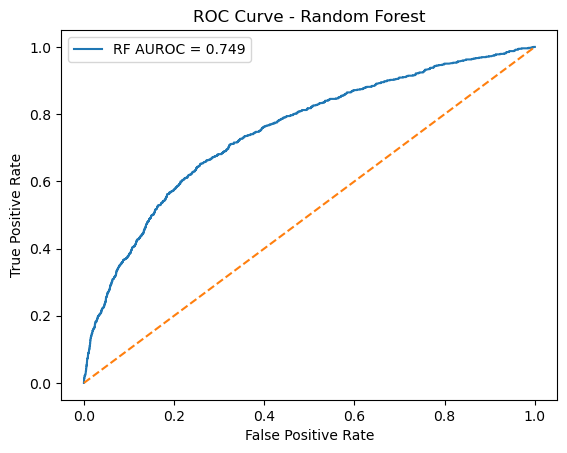

In [25]:
## Calculate false positive rate (FPR) and true positive
## rate (TPR) across all classification thresholds
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)


## Plot ROC curve
plt.plot(fpr_rf, tpr_rf, label=f"RF AUROC = {auc_rf:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

## Display the ROC curve
plt.show()

In [26]:
## Create feature importance table for RF model
feature_importance = pd.DataFrame({
    'RF Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

## Display the feature importance table for the RF model
feature_importance

,RF Feature,Importance
0,age,0.208317
22,ip_admit_utilization_moderate,0.129341
5,los_days_capped,0.118202
17,med_risk_high,0.088668
21,ip_admit_utilization_low,0.060224
23,ip_admit_utilization_high,0.044922
16,med_risk_medium,0.034747
3,dispo_transfer,0.033566
1,gender_female,0.029165
18,ed_low,0.026927


In [27]:
#### GRADIENT BOOSTING ####

# Create a Gradient Boosting machine learning model

## Import Gradient Boosting (GB) model
from xgboost import XGBClassifier

## Calculate imbalance weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

## Create GB model (w/ weighted classes)
gb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=123,
    eval_metric='logloss'
)

## Train the model
gb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
## Make predictions
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

## Calculate the AUC value
auc_gb = roc_auc_score(y_test, y_prob_gb)

## Display the AUC value
print("GB AUC:", auc_gb)

GB AUC: 0.7559203447713553


In [29]:
## Create the GB confusion matrix
gb_cm = confusion_matrix(y_test, y_pred_gb)

## Display the GB confusion matrix
print("GB Confusion Matrix (Threshold = 0.5)")
print("_____________________________________")
print(gb_cm)

GB Confusion Matrix (Threshold = 0.5)
_____________________________________
[[5631 1450]
 [ 295  429]]


In [30]:
## Create and display the GB classification report
print("GB Classification Report (Threshold = 0.5)")
print("_____________________________________________________")
print(classification_report(y_test, y_pred_gb))

GB Classification Report (Threshold = 0.5)
_____________________________________________________
              precision    recall  f1-score   support

           0       0.95      0.80      0.87      7081
           1       0.23      0.59      0.33       724

    accuracy                           0.78      7805
   macro avg       0.59      0.69      0.60      7805
weighted avg       0.88      0.78      0.82      7805



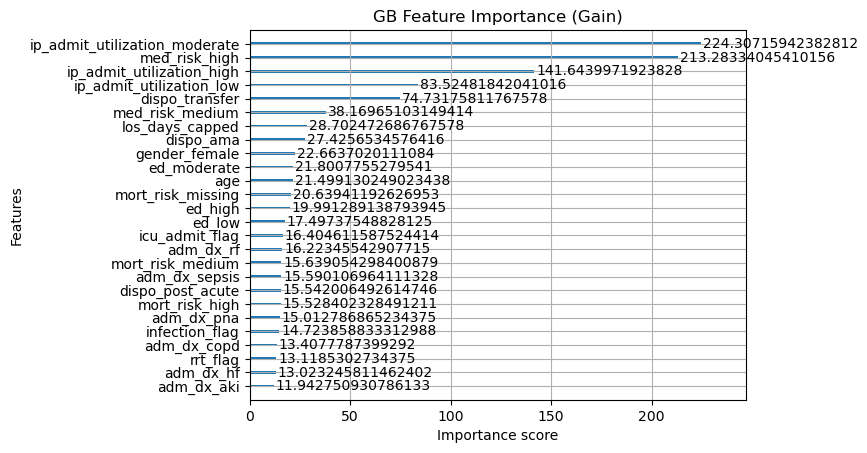

In [31]:
## Import feature importance chart
from xgboost import plot_importance

## Create GB feature importance (gain) chart
plot_importance(gb, importance_type='gain')
plt.title("GB Feature Importance (Gain)")

## Display GB feature importance (gain) chart
plt.show()

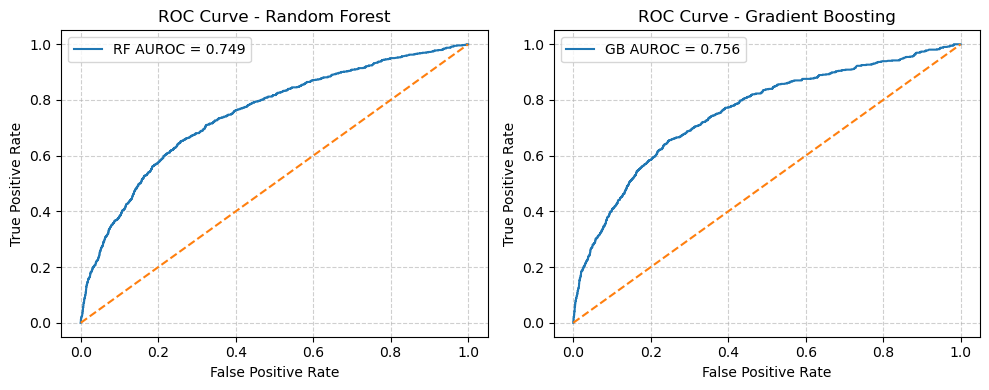

In [32]:
## Create RF and GB side-by-side plots

# ROC values
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gb = roc_auc_score(y_test, y_prob_gb)

## Side-by-side figure parameters
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

## RF ROC plot parameters
axes[0].plot(fpr_rf, tpr_rf, label=f"RF AUROC = {auc_rf:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle='--')
axes[0].set_title('ROC Curve - Random Forest')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

## GB ROC plot parameters
axes[1].plot(fpr_gb, tpr_gb, label=f"GB AUROC = {auc_gb:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('ROC Curve - Gradient Boosting')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

## Display side-by-side plots for RF and GB ROC curves
plt.tight_layout()
plt.show()

In [38]:
#### DELONG'S TEST ####

## Import the stats module from SciPy library
from scipy import stats

## Create DeLong's Test function
def delong_roc_test(y_true, y_pred1, y_pred2):
    
    ### Set number of bootstrap samples
    n_bootstraps = 1000
    
    ## Set random state
    rng = np.random.RandomState(123)

    ### Store AUROC difference
    auc_diffs = []

    ### Repeat bootstrap sampling process 1000 times
    for _ in range(n_bootstraps):
        indices = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue

        #### Calculate AUROC    
        auc1 = roc_auc_score(y_true.iloc[indices], y_pred1[indices])
        auc2 = roc_auc_score(y_true.iloc[indices], y_pred2[indices])

        #### Store AUROC difference
        auc_diffs.append(auc1 - auc2)

    ### Transfer results into NumPy array    
    auc_diffs = np.array(auc_diffs)
    
    ### Calculate mean and standard deviation of AUROC differences
    mean_diff = np.mean(auc_diffs)
    std_diff = np.std(auc_diffs)

    ### Calculate z-score and p-value
    z_score = mean_diff / std_diff
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

    ### Return p-value for model comparison
    return p_value

In [39]:
## Run DeLong's Test: LR vs RF
dlt_lr_rf = delong_roc_test(y_test, y_prob, y_prob_rf)

## Run DeLong's Test: LR vs GB
dlt_lr_gb = delong_roc_test(y_test, y_prob, y_prob_gb)

## Display DeLong's Test results
print("DeLong's Test - AUROC Comparisons")
print("_____________________________________")
print("LR vs RF p-value:", dlt_lr_rf)
print("LR vs GB p-value:", dlt_lr_gb)

DeLong's Test - AUROC Comparisons
_____________________________________
LR vs RF p-value: 0.6991787880344789
LR vs GB p-value: 0.06644610838854659
